# Проект. Исследование стартапов

Автор: Петрунин Богдан  
Дата: 20.07.2026

## Введение

**Цель:** Подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий, с целью формирования обоснованных рекомендаций для венчурной компании по выбору направлений и инструментов инвестирования в условиях 2015 года.  

**Задачи:**
- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период - исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.  

**Содержание:** 
1. Введение
2. Знакомство с данными: загрузка и предобработка
 - 2.1. Вывод общей информации
 - 2.2. Предобработка данных
3. Инжиниринг признаков
 - 3.1. Группы по срокам финансирования
 - 3.2 Выделение средних и нишевых сегментов рынка
4. Работа с выбросами и анализ
 - 4.1. Анализируем и помечаем выбросы в каждом из сегментов
 - 4.2 Определяем границы рассматриваемого периода, отбрасываем аномалии
 - 4.3. Анализ типов финансирования по объёму и популярности
5. Анализ динамики
 - 5.1 Динамика предоставления финансирования по годам
 - 5.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
 - 5.3 Годовая динамика доли возвращённых средств по типам финансирования
6. Итоговый вывод и рекомендации



##  Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### Вывод общей информации


In [1]:
# Импортируем библиотеку для анализа данных
import pandas as pd

# Загрузим библиотки maplotlib и seaborn для визуализации 
import matplotlib.pyplot as plt
import seaborn as sns

Загрузим датасеты `cb_investments.zip` и `cb_returns.csv`

In [2]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
cb = pd.read_csv("/datasets/cb_returns.csv")

Выведем информацию о каждом датасете с помощью методов `info` и `head`

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
initial_rows = len(df)

Датасет `df` содержит 54 294 записи о компаниях и 40 столбцов. Данные представляют собой смесь категориальных (object), количественных (float64) и временных признаков, что позволяет провести многофакторный анализ инвестиционной активности.  

**Проблемы с типами данных:**
- Столбец `funding_total_usd` имеет тип object, хотя должен быть числовым (float/int). Вероятно, в нем содержатся символы (запятые, знаки доллара, текст типа "unknown"), что делает невозможным прямой расчет сумм. 
- Даты (`founded_at`, `first_funding_at` и др.) также имеют тип object — их необходимо привести к формату datetime для анализа динамики по годам.  

**Пропуски:** Критические столбцы (`funding_total_usd`, `funding_rounds`, все финансовые поля, name) имеют одинаковое количество пропусков — 4 856, что говорит об отсутствии данных по одним и тем же компаниям. Эти строки необходимо удалить.

In [7]:
cb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [8]:
cb.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Датасет `cb_returns` представляет собой чистый, полный и структурированный набор данных о возвратах инвестиций по годам. Он не требует обработки пропусков или приведения типов. 
Основное внимание при предобработке следует уделить:
- Анализу нулевых значений и их интерпретации (фактические нули против пропусков).
- Выявлению и обработке потенциальных выбросов (например, резкий скачок venture в 2004 году).
- Оценке информативности столбцов с преобладанием нулевых значений (`equity_crowdfunding`, `grant`) для возможного исключения.
- Согласованию временного периода с основным датасетом `cb_investments` для корректного совместного анализа.
- Датасет готов к использованию в расчётах доли возврата средств и оценке устойчивости различных типов финансирования.

**Промежуточный вывод:**
- Датасет `df` содержит 54 294 строки и 40 столбцов, однако максимальное количество непустых значений в любом столбце составляет 49 438, что указывает на наличие значительного числа пропусков. Наиболее критическая проблема заключается в том, что у примерно 9% компаний (4 856 записей) полностью отсутствуют финансовые данные — это касается столбцов `funding_total_usd`, всех полей с суммами инвестиций по типам и раундам, а также `funding_rounds`. При этом названия компаний `name` также отсутствуют у 4 857 записей, что практически совпадает с числом компаний без финансовых данных, поэтому удаление строк с пропущенными названиями одновременно решит проблему с отсутствием финансовых показателей. 
- В отличие от первого датасета, `cb` представляет собой полностью чистый и структурированный набор данных: он содержит 15 записей (по годам с 2000 по 2014) и 14 столбцов, все из которых имеют 100% заполнение и корректные типы данных (year — целочисленный, остальные — числа с плавающей точкой). Пропуски в этом датасете полностью отсутствуют, однако при детальном рассмотрении обнаруживаются нулевые значения в некоторых столбцах (equity_crowdfunding, grant), которые являются фактическими нулями возвратов, а не пропусками, и требуют правильной интерпретации при расчётах. Кроме того, в данных наблюдаются разные масштабы значений по типам финансирования (например, `venture` достигает сотен миллионов долларов, тогда как `post_ipo_debt` измеряется единицами), а также потенциальные выбросы, такие как резкий скачок венчурных возвратов в 2004 году до 555,90 млн долларов.




### Предобработка данных

Проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведем их к единому аккуратному стилю.

In [9]:
# Проверим названия столбцов датасета df 
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Названия столбцов в датасете `
cb` в целом корректны и информативны. Основной стиль — snake_case уже используется в большинстве столбцов, что является оптимальным для работы, однако, в столбцах `market`, `funding_total_usd`,`funding_total_usd` имеются лишние пробелы.

In [10]:
# Уберем лишние пробелы в названиях столбцов 
df.columns = df.columns.str.strip()

In [11]:
cb.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Названия столбцов в датасете `cb` корректны и информативны.

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [12]:
# Уберем посторонние символы 
df['funding_total_usd'] = (df['funding_total_usd'].astype(str) 
                           .str.replace(',', '',regex=False)          
                           .str.replace('$', '',regex=False)          
                           .str.replace(' - ', '',regex=False)        
                           .str.replace('-', '',regex=False)) 

# Приведём столбец к числовому типу 
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')

Обработаем типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [13]:
# Проверяем типы данных всех столбцов с датами
date_columns = ['founded_at', 'founded_month', 'founded_quarter', 'founded_year', 
                'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_columns:
    print(f"{col}: {df[col].dtype}")

founded_at: object
founded_month: object
founded_quarter: object
founded_year: float64
first_funding_at: object
mid_funding_at: object
last_funding_at: object


In [14]:
# Преобразуем основные даты
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], errors='coerce')
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], errors='coerce')
df['mid_funding_at'] = pd.to_datetime(df['mid_funding_at'], errors='coerce')
df['founded_month'] = pd.to_datetime(df['founded_month'], errors='coerce')

In [15]:
for col in date_columns:
    print(f"{col}: {df[col].dtype}")

founded_at: datetime64[ns]
founded_month: datetime64[ns]
founded_quarter: object
founded_year: float64
first_funding_at: datetime64[ns]
mid_funding_at: datetime64[ns]
last_funding_at: datetime64[ns]


В датасете `cb` сделаем столбец `year` индексом всего датасета.

In [16]:
cb.set_index('year', inplace=True)
cb.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Теперь подсчитаем пропуски и решим, что с ними делать

In [17]:
# Создание сводной таблицы с пропусками
missing_df = pd.DataFrame({
    'Абсолютные': df.isnull().sum(),
    'Относительные (%)': (df.isnull().sum() / len(df)) * 100
})
display("Сводная таблица пропусков:")
display(missing_df)

'Сводная таблица пропусков:'

,Абсолютные,Относительные (%)
name,4857,8.945740
homepage_url,8305,15.296350
category_list,8817,16.239363
market,8817,16.239363
funding_total_usd,13387,24.656500
status,6170,11.364055
country_code,10129,18.655837
state_code,24133,44.448742
region,10129,18.655837
city,10972,20.208494


Обработаем текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполним
заглушками.

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.


In [18]:
# Заполняем пропуски в текстовых столбцах
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].fillna('unknown')

In [19]:
# Удаляем дубликаты
df = df.drop_duplicates()

In [20]:
# Удаляем строки без информации о финансировании
df = df.dropna(subset=['funding_total_usd'])

In [21]:
# Находим строки, где mid_funding_at - пропуск
mask = df['mid_funding_at'].isna()

# Заполняем пропуски серединой между first и last
df.loc[mask, 'mid_funding_at'] = ( 
    df.loc[mask, 'first_funding_at'] + 
    (df.loc[mask, 'last_funding_at'] - df.loc[mask, 'first_funding_at']) / 2
)

Оценим размер оставшихся пропусков в столбце.

In [22]:
display("Сводная таблица пропусков:")
display(df.isnull().sum())

'Сводная таблица пропусков:'

name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            13576
founded_at               8707
founded_month            8772
founded_quarter             0
founded_year             8706
first_funding_at            2
mid_funding_at              1
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_A                     0
round_B   

Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта.Узнаем  какой процент данных был отброшен.

In [23]:
final_rows = len(df)
# Рассчитываем процент отброшенных данных
removed_rows = initial_rows - final_rows
removed_percent = (removed_rows / initial_rows) * 100
retained_percent = (final_rows / initial_rows) * 100
# Выводим результаты
print(f"Исходное количество строк: {initial_rows:,}")
print(f"Количество строк после обработки: {final_rows:,}")
print(f"Отброшено строк: {removed_rows:,}")
print(f"Процент отброшенных данных: {removed_percent:.2f}%")
print(f"Процент сохраненных данных: {retained_percent:.2f}%")


Исходное количество строк: 54,294
Количество строк после обработки: 40,907
Отброшено строк: 13,387
Процент отброшенных данных: 24.66%
Процент сохраненных данных: 75.34%


В ходе предварительной обработки данных из исходного набора, содержащего 54 294 строк, было исключено 13 387 строк, что составляет 24,66% от общего объема данных. В итоговый датасет для дальнейшего анализа вошло 40 907 строк, что соответствует 75,34% от первоначального объема. Потери данных превышают 20%, что указывает на значительный уровень отбраковки, однако оставшийся объем данных (более 40 тысяч записей) является достаточным для проведения статистически значимого анализа и решения задач проекта.

## Инжиниринг признаков

### Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

In [24]:
# Список столбцов с раундами
all_rounds = ['round_A', 'round_B', 'round_C', 'round_D', 'round_E', 
              'round_F', 'round_G', 'round_H']

# Функция для определения группы
def get_group(row):
# Считаем количество раундов
    rounds_count = row['funding_rounds']
    
# Если 1 раунд 
    if rounds_count == 1:
        return 'Единичное финансирование'
    # Если нет данных о датах
    if pd.isna(row['first_funding_at']) or pd.isna(row['last_funding_at']):
        return 'Единичное финансирование'
    
# Считаем дни между первым и последним раундом
    days = (row['last_funding_at'] - row['first_funding_at']).days
    
    if days <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

# Применяем функцию
df['group'] = df.apply(get_group, axis=1)

In [25]:
# Считаем статистику по группам
stats = df.groupby('group').agg({
    'name': 'count',
    'funding_total_usd': 'sum'
}).rename(columns={'name': 'count', 'funding_total_usd': 'sum'})

# Добавляем проценты
stats['count_percent'] = (stats['count'] / stats['count'].sum()) * 100
stats['funding_percent'] = (stats['sum'] / stats['sum'].sum()) * 100

stats

,count,sum,count_percent,funding_percent
group,,,,
Единичное финансирование,24115,1.993387e+11,58.950791,30.623506
Срок финансирования более года,12291,4.027090e+11,30.046202,61.866361
Срок финансирования до года,4501,4.888598e+10,11.003007,7.510132


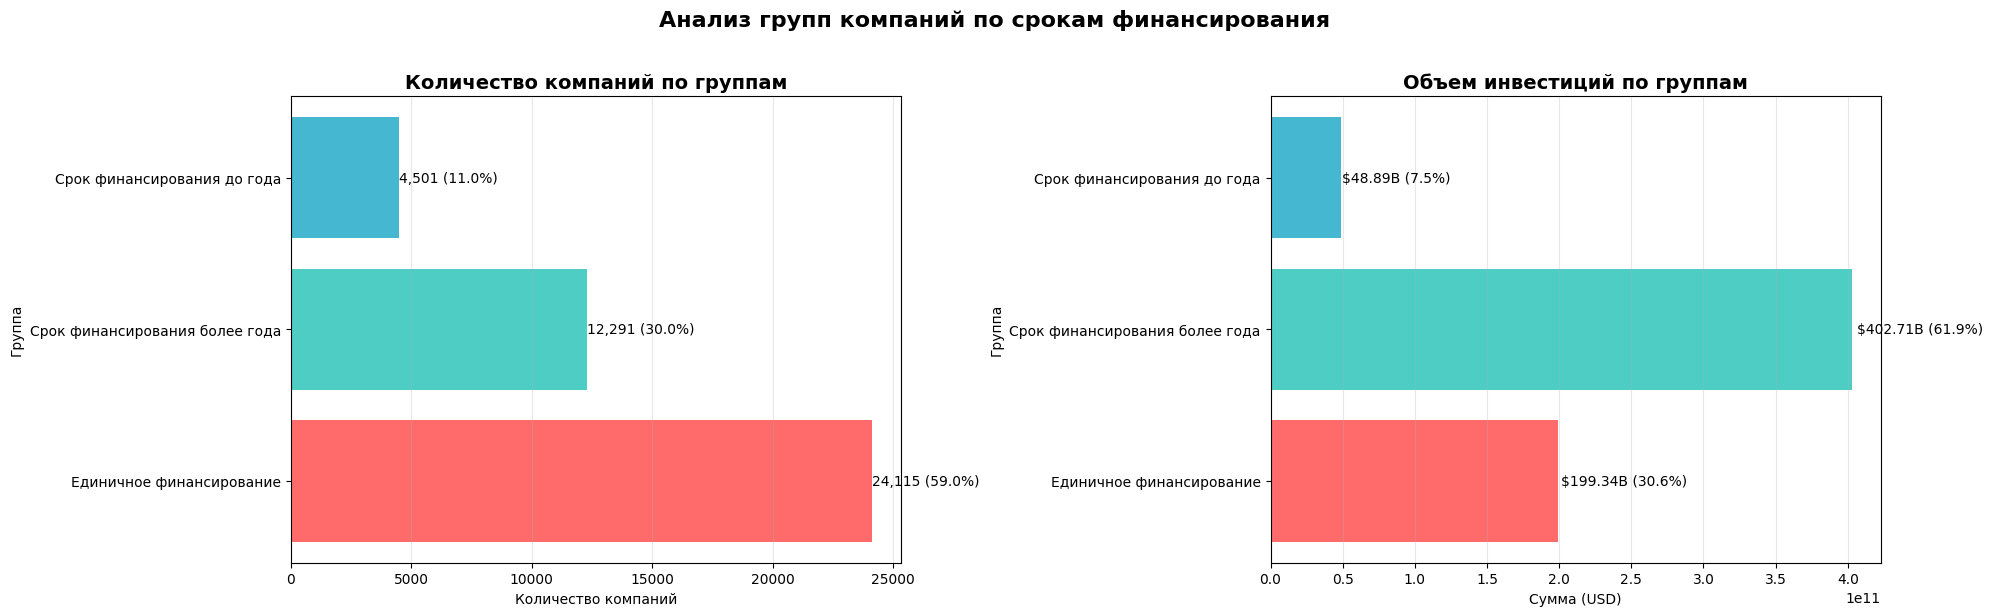

In [26]:
# Цвета
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Создаем два графика
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# График 1: по компаниям 
bars1 = ax1.barh(stats.index, stats['count'], color=colors)
ax1.set_title('Количество компаний по группам', fontsize=14, weight='bold')
ax1.set_xlabel('Количество компаний')
ax1.set_ylabel('Группа')
ax1.grid(axis='x', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(stats['count']):
    ax1.text(v + 5, i, f'{v:,} ({stats["count_percent"].iloc[i]:.1f}%)', 
             va='center', fontsize=10)

# График 2: по инвестициям 
bars2 = ax2.barh(stats.index, stats['sum'], color=colors)
ax2.set_title('Объем инвестиций по группам', fontsize=14, weight='bold')
ax2.set_xlabel('Сумма (USD)')
ax2.set_ylabel('Группа')
ax2.grid(axis='x', alpha=0.3)

# Форматируем значения
def format_currency(x):
    if x >= 1e9:
        return f'${x/1e9:.2f}B'
    elif x >= 1e6:
        return f'${x/1e6:.2f}M'
    else:
        return f'${x:,.0f}'

# Добавляем значения на столбцы
for i, v in enumerate(stats['sum']):
    ax2.text(v + v*0.01, i, f'{format_currency(v)} ({stats["funding_percent"].iloc[i]:.1f}%)', 
             va='center', fontsize=10)

plt.suptitle('Анализ групп компаний по срокам финансирования', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Основные результаты:**
- Наибольшую долю среди всех компаний составляют компании с единичным финансированием — 59% (24 115 компаний). Это означает, что большинство компаний в выборке привлекли инвестиции только один раз и не продолжили привлекать финансирование в последующих раундах.

- Срок финансирования до года характерен для 11% компаний (4 501 компания). Это относительно небольшая группа, которая, вероятно, представляет собой компании на ранних стадиях с быстрым циклом привлечения инвестиций.

- Срок финансирования более года имеют 30% компаний (12 291 компания). Это вторая по величине группа, что указывает на значительное количество компаний с долгосрочной инвестиционной историей.

По объёму инвестиций картина меняется:

- Компании с единичным финансированием привлекли 30.6% всех инвестиций, что непропорционально мало по сравнению с их долей в количестве компаний (59%).

- Компании со сроком финансирования более года собрали 61.9% всех инвестиций — это самая привлекательная для инвесторов группа, несмотря на то, что их доля составляет всего 30% от общего числа компаний.

- Компании со сроком финансирования до года получили лишь 7.5% от общего объёма инвестиций.

**Общий вывод:**

Выборка характеризуется преобладанием компаний с единичным раундом финансирования, однако основной объём инвестиций сконцентрирован в компаниях с долгосрочной инвестиционной историей (более года). Это свидетельствует о том, что инвесторы предпочитают вкладывать средства в компании с подтверждённой способностью привлекать финансирование на протяжении длительного времени, а не в компании с разовым привлечением инвестиций. Для дальнейшего анализа целесообразно фокусироваться на компаниях с долгосрочным финансированием, как на наиболее инвестиционно привлекательной группе.



### Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [27]:
# Считаем количество компаний в каждом сегменте
market_counts = df['market'].value_counts()

print("Топ-10 сегментов по количеству компаний:")
print(market_counts.head(20))

# Категоризируем сегменты
def categorize_segment(count):
    if count > 120:
        return 'Массовый'
    elif 35 <= count <= 120:
        return 'Средний'
    else:
        return 'Нишевый'

# Создаем DataFrame с категориями
segment_stats = pd.DataFrame({
    'count': market_counts,
    'category': market_counts.apply(categorize_segment)
})

# Считаем количество сегментов в каждой категории
category_counts = segment_stats['category'].value_counts()
print("Количество сегментов по категориям:")
display(category_counts)


# Считаем количество компаний в каждой категории
companies_in_category = segment_stats.groupby('category')['count'].sum()
print("Количество компаний в каждой категории:")
display(companies_in_category)

category
Нишевый     714
Средний      81
Массовый     54
Name: count, dtype: int64

category
Массовый    33344
Нишевый      2494
Средний      5069
Name: count, dtype: int64

Топ-10 сегментов по количеству компаний:
market
 Software                4190
 Biotechnology           3531
unknown                  2503
 Mobile                  1852
 E-Commerce              1528
 Curated Web             1404
 Enterprise Software     1190
 Health Care             1128
 Clean Technology        1094
 Hardware + Software     1008
 Games                    986
 Advertising              954
 Health and Wellness      825
 Social Media             787
 Education                736
 Finance                  728
 Analytics                565
 Manufacturing            564
 Security                 491
 Semiconductors           473
Name: count, dtype: int64
Количество сегментов по категориям:
Количество компаний в каждой категории:


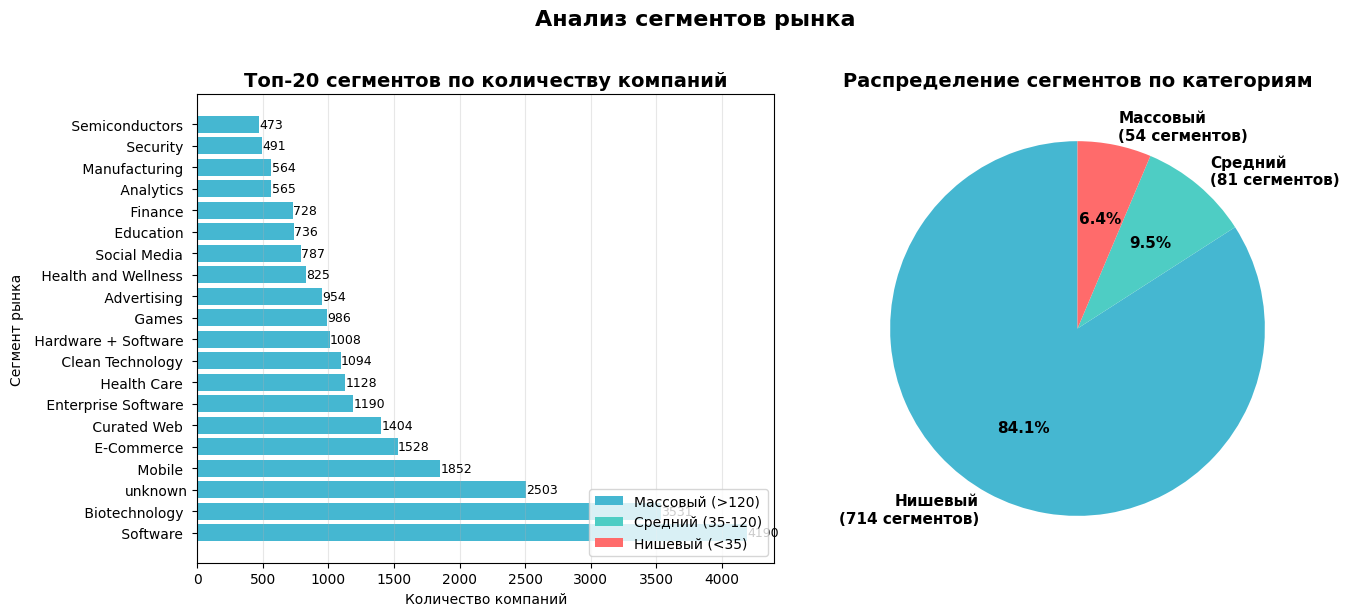

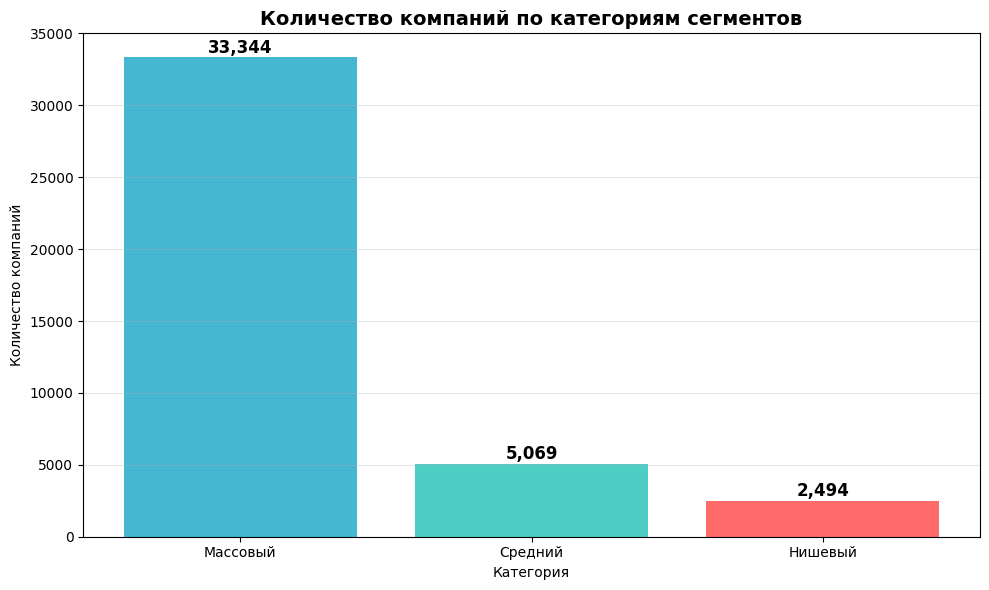

In [28]:
# Визуализация распределения сегментов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Гистограмма распределения сегментов по размеру
top_segments = market_counts.head(20)
top_segments_sorted = top_segments.sort_values(ascending=False)

# Цвета для столбцов в зависимости от категории
colors_segments = []
for seg in top_segments.index:
    count = top_segments[seg]
    if count > 120:
        colors_segments.append('#45B7D1')  
    elif 35 <= count <= 120:
        colors_segments.append('#4ECDC4')  
    else:
        colors_segments.append('#FF6B6B') 

# Строим столбчатую диаграмму
bars = ax1.barh(top_segments.index, top_segments_sorted, color=colors_segments)
ax1.set_title('Топ-20 сегментов по количеству компаний', fontsize=14, weight='bold')
ax1.set_xlabel('Количество компаний')
ax1.set_ylabel('Сегмент рынка')
ax1.grid(axis='x', alpha=0.3)

# Добавляем значения
for i, v in enumerate(top_segments.values):
    ax1.text(v + 2, i, str(v), va='center', fontsize=9)

# Легенда для цветов
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#45B7D1', label='Массовый (>120)'),
    Patch(facecolor='#4ECDC4', label='Средний (35-120)'),
    Patch(facecolor='#FF6B6B', label='Нишевый (<35)')
]
ax1.legend(handles=legend_elements, loc='lower right')

# График 2: Распределение по категориям 
# По количеству сегментов
ax2.pie(
    category_counts,
    labels=[f'{cat}\n({count} сегментов)' for cat, count in category_counts.items()],
    autopct='%1.1f%%',
    colors=['#45B7D1', '#4ECDC4', '#FF6B6B'],
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold'}
)
ax2.set_title('Распределение сегментов по категориям', fontsize=14, weight='bold')

plt.suptitle('Анализ сегментов рынка', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Дополнительный график: распределение компаний по категориям
fig, ax = plt.subplots(figsize=(10, 6))

# Сортируем категории
category_order = ['Массовый', 'Средний', 'Нишевый']
companies_sorted = [companies_in_category[cat] for cat in category_order if cat in companies_in_category.index]
colors_cat = ['#45B7D1', '#4ECDC4', '#FF6B6B']

bars = ax.bar(category_order, companies_sorted, color=colors_cat)
ax.set_title('Количество компаний по категориям сегментов', fontsize=14, weight='bold')
ax.set_xlabel('Категория')
ax.set_ylabel('Количество компаний')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(companies_sorted):
    ax.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.


In [29]:
# Сначала считаем частоту каждого сегмента
market_counts = df['market'].value_counts()

# Функция для замены
def get_market_category(market):
    count = market_counts[market]  # получаем количество компаний в сегменте
    
    if count > 120:
        return market  # массовые сегменты оставляем как есть
    elif 35 <= count <= 120:
        return 'mid'   # средние сегменты
    else:
        return 'niche' # нишевые сегменты

# Применяем функцию к столбцу
df['market'] = df['market'].apply(get_market_category)

# Проверяем результат
df['market'].value_counts()

market
mid                       5069
 Software                 4190
 Biotechnology            3531
unknown                   2503
niche                     2494
 Mobile                   1852
 E-Commerce               1528
 Curated Web              1404
 Enterprise Software      1190
 Health Care              1128
 Clean Technology         1094
 Hardware + Software      1008
 Games                     986
 Advertising               954
 Health and Wellness       825
 Social Media              787
 Education                 736
 Finance                   728
 Analytics                 565
 Manufacturing             564
 Security                  491
 Semiconductors            473
 Web Hosting               400
 Consulting                322
 Hospitality               313
 Travel                    293
 Fashion                   285
 News                      284
 Messaging                 264
 Real Estate               251
 Music                     246
 Search                    242
S

Анализ сегментов рынка показывает, что в датасете представлено 849 уникальных сегментов, что свидетельствует о высоком уровне разнообразия представленных компаний. При этом распределение компаний по сегментам крайне неравномерно: 84,1% всех сегментов (714) являются нишевыми и содержат менее 35 компаний каждый, в сумме охватывая всего 2 494 компании (6,1% от общего числа). Средние сегменты (от 35 до 120 компаний) составляют 9,5% (81 сегмент) и включают 5 069 компаний (12,4%). На долю массовых сегментов (более 120 компаний) приходится лишь 6,4% (54 сегмента), однако они концентрируют основную часть компаний — 33 344 компании (81,5%) от всей выборки.

Лидерами по числу компаний являются сегменты Software (4 190 компаний), Biotechnology (3 531) и Mobile (1 852), что указывает на доминирование технологических и биотехнологических направлений.

Таким образом, несмотря на широкое разнообразие сегментов, рынок характеризуется ярко выраженной концентрацией: небольшая группа массовых сегментов охватывает подавляющее большинство компаний, тогда как основная масса сегментов является нишевой и содержит незначительное число игроков. Для дальнейшего анализа целесообразно сфокусироваться на массовых сегментах как на наиболее репрезентативных, а нишевые и средние сегменты объединить в общие категории niche и mid соответственно для упрощения модели и повышения статистической значимости выводов.



##  Работа с выбросами и анализ

### Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

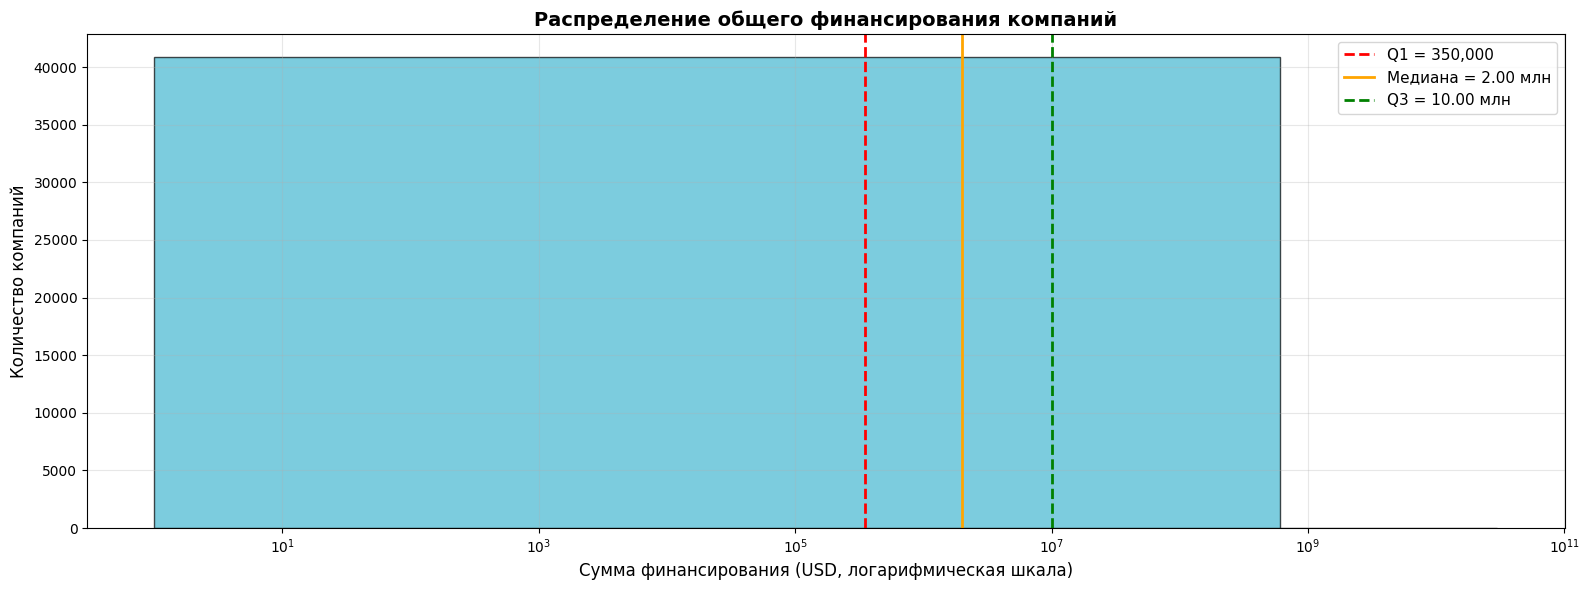

count     : 40,907 компаний
mean      : 15.91 млн USD
std       : 168.68 млн USD
min       : 1 USD
25%       : 350,000 USD
50%       : 2.00 млн USD
75%       : 10.00 млн USD
max       : 30.08 млрд USD
Типичные значения интервала:
От 350,000 до 10.00 млн USD


In [30]:
# Функция для форматирования денег
def format_money(x):
    if pd.isna(x):
        return 'N/A'
    if x >= 1e9:
        return f'{x/1e9:.2f} млрд'
    elif x >= 1e6:
        return f'{x/1e6:.2f} млн'
    else:
        return f'{x:,.0f}'

# Статистика
stats = df['funding_total_usd'].describe(percentiles=[0.25, 0.5, 0.75])
for stat, value in stats.items():
    if stat == 'count':
        print(f"{stat:10}: {value:,.0f} компаний")
    else:
        print(f"{stat:10}: {format_money(value)} USD")

# Типичный интервал
Q1 = stats['25%']
Q3 = stats['75%']

print(f"Типичные значения интервала:")
print(f"От {format_money(Q1)} до {format_money(Q3)} USD")

# Гистограмма
fig, ax = plt.subplots(figsize=(16, 6))

ax.hist(df['funding_total_usd'], bins=50, color='#45B7D1', edgecolor='black', alpha=0.7)
ax.set_xscale('log')

# Линии
ax.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 = {format_money(Q1)}')
ax.axvline(stats['50%'], color='orange', linestyle='-', linewidth=2, 
           label=f'Медиана = {format_money(stats["50%"])}')
ax.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 = {format_money(Q3)}')

# Подписи
ax.set_title('Распределение общего финансирования компаний', fontsize=14, weight='bold')
ax.set_xlabel('Сумма финансирования (USD, логарифмическая шкала)', fontsize=12)
ax.set_ylabel('Количество компаний', fontsize=12)


ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Средний размер финансирования составляет 15,91 млн USD, однако медианное значение значительно ниже — 2,00 млн USD. Такое расхождение указывает на сильную правостороннюю асимметрию распределения: большинство компаний привлекают относительно небольшие суммы, а несколько крупных сделок значительно увеличивают среднее значение.

Типичный интервал для большинства компаний (от 25-го до 75-го перцентиля) находится в диапазоне от 350 тыс. до 10,00 млн USD. Это означает, что 50% всех компаний имеют общий объём финансирования в указанных границах.

При этом разброс значений чрезвычайно широк: минимальное зафиксированное значение составляет всего 1 USD, а максимальное достигает 30,08 млрд USD, что в тысячи раз превышает медиану. Стандартное отклонение в 168,68 млн USD также подтверждает высокую вариативность данных.

Таким образом, типичным для рассматриваемой выборки можно считать размер финансирования в пределах от 350 тыс. до 10 млн USD. Значения, существенно превышающие верхнюю границу межквартильного интервала (особенно более 10 млн USD), следует рассматривать как выбивающиеся — они соответствуют крупным, зрелым компаниям или сделкам, которые не репрезентативны для основной массы стартапов и требуют отдельного анализа.

Далее определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту. 
Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

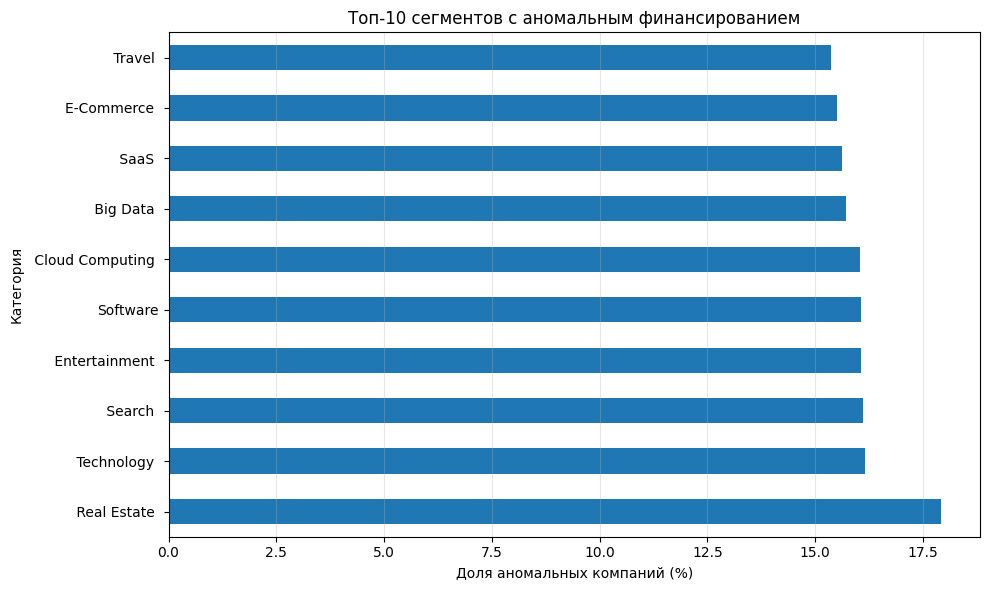

Топ-10 сегментов с аномально высоким финансированием:
market
 Real Estate         17.9
 Technology          16.2
 Search              16.1
 Entertainment       16.1
Software             16.1
 Cloud Computing     16.0
 Big Data            15.7
 SaaS                15.6
E-Commerce           15.5
 Travel              15.4
Name: outlier, dtype: float64


In [31]:
# Определяем выбросы
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    return group > upper  # только верхние выбросы (аномально высокие)

df['outlier'] = df.groupby('market')['funding_total_usd'].transform(find_outliers)

# Результаты
outlier_stats = df.groupby('market')['outlier'].mean().sort_values(ascending=False) * 100

print("Топ-10 сегментов с аномально высоким финансированием:")
print(outlier_stats.head(10).round(1))

# График
outlier_stats.head(10).plot(kind='barh', figsize=(10, 6))
plt.xlabel('Доля аномальных компаний (%)')
plt.ylabel('Категория')
plt.title('Топ-10 сегментов с аномальным финансированием')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Среди всех сегментов лидирующие позиции по доле компаний с аномальным финансированием занимают Real Estate (17,9%), Technology (16,2%), Search (16,1%), Entertainment (16,1%) и Software (16,1%). Также высокие показатели демонстрируют Cloud Computing (16,0%), Big Data (15,7%), SaaS (15,6%), E-Commerce (15,5%) и Travel (15,4%).

Обращает на себя внимание, что в топ-10 вошли преимущественно массовые сегменты (Software, E-Commerce, Technology, SaaS), что объясняется большим количеством компаний в этих категориях и, как следствие, более широким разбросом объёмов финансирования. При этом в таких сегментах, как Real Estate и Travel, доля аномальных значений также высока, что может свидетельствовать о наличии небольшого числа крупных сделок на фоне множества небольших компаний.

В целом, доля компаний с аномально высоким финансированием в топ-сегментах варьируется в диапазоне 15–18%, что указывает на умеренный уровень аномалий. Это означает, что в каждом из указанных сегментов примерно каждая шестая компания привлекла объём инвестиций, существенно превышающий типичные для данного сегмента значения.


###  Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [32]:
# Создаем столбцы с годом и месяцем
df['funding_year'] = df['mid_funding_at'].dt.year
df['funding_month'] = df['mid_funding_at'].dt.month

# Количество компаний по годам 
companies_by_year = df.groupby('funding_year')['name'].count()
print("Количество компаний по годам:")
print(companies_by_year)

# Проверяем 2014 год
if 2014 in df['funding_year'].values:
    df_2014 = df[df['funding_year'] == 2014]
    monthly_counts = df_2014.groupby('funding_month').size()
    print("\nКоличество компаний в каждом месяце (2014):")
    for month in range(1, 13):
        count = monthly_counts.get(month, 0)
        print(f"Месяц {month:2d}: {count:5d} компаний")
    
    print(f"Всего компаний в 2014: {len(df_2014)}")

# Исключаем компании с аномальным финансированием
before = len(df)
df = df[df['outlier'] == False]
after = len(df)

print(f"Было: {before} компаний")
print(f"Стало: {after} компаний")
print(f"Удалено аномалий: {before - after} компаний ({ (before - after)/before*100:.2f}%)")

Количество компаний по годам:
funding_year
1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       4
1996.0       4
1997.0       7
1998.0      13
1999.0      50
2000.0     103
2001.0      63
2002.0      70
2003.0      90
2004.0     150
2005.0     843
2006.0    1463
2007.0    2107
2008.0    2588
2009.0    3237
2010.0    4094
2011.0    4863
2012.0    6089
2013.0    8423
2014.0    6619
Name: name, dtype: int64

Количество компаний в каждом месяце (2014):
Месяц  1:   739 компаний
Месяц  2:   600 компаний
Месяц  3:   676 компаний
Месяц  4:   645 компаний
Месяц  5:   600 компаний
Месяц  6:   740 компаний
Месяц  7:   687 компаний
Месяц  8:   559 компаний
Месяц  9:   547 компаний
Месяц 10:   497 компаний
Месяц 11:   306 компаний
Месяц 12:    23 компаний
Всего компаний в 2014: 6619
Было: 40907 компаний
Стало: 35705 компаний
Удалено аномалий: 520

In [33]:
# Считаем количество раундов по годам (после удаления аномалий)
rounds_by_year = df.groupby('funding_year')['funding_rounds'].sum()

print("Количество раундов по годам (после удаления аномалий):")
print(rounds_by_year)

# Находим годы с 50+ раундами
years_with_50_plus = rounds_by_year[rounds_by_year >= 50].index.tolist()
print(f"\nГоды с 50+ раундами: {years_with_50_plus}")

# Оставляем только компании из этих годов
before = len(df)
df = df[df['funding_year'].isin(years_with_50_plus)]
after = len(df)

print(f"\nДо фильтрации: {before} компаний")
print(f"После фильтрации: {after} компаний")
print(f"Удалено: {before - after} компаний")

# Проверяем распределение по годам после фильтрации
print("\nРаспределение по годам после фильтрации:")
print(df.groupby('funding_year')['funding_rounds'].count())

Количество раундов по годам (после удаления аномалий):
funding_year
1921.0        1.0
1960.0        2.0
1979.0        1.0
1982.0        3.0
1983.0        1.0
1984.0        2.0
1985.0        3.0
1987.0        2.0
1989.0        1.0
1990.0        1.0
1992.0        5.0
1993.0        1.0
1994.0        4.0
1995.0        9.0
1996.0        8.0
1997.0        9.0
1998.0       15.0
1999.0       43.0
2000.0      117.0
2001.0       66.0
2002.0       98.0
2003.0      129.0
2004.0      172.0
2005.0      943.0
2006.0     1852.0
2007.0     2842.0
2008.0     3671.0
2009.0     4647.0
2010.0     6146.0
2011.0     7580.0
2012.0     9706.0
2013.0    12907.0
2014.0     7146.0
Name: funding_rounds, dtype: float64

Годы с 50+ раундами: [2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]

До фильтрации: 35705 компаний
После фильтрации: 35629 компаний
Удалено: 76 компаний

Распределение по годам после фильтрации:
funding_year
2000.0      66
200

Анализ данных показал, что в датасете присутствуют компании с финансированием начиная с 1921 года, однако основная активность наблюдается с 2000-х годов. Наибольшее количество компаний было зафиксировано в 2013 году (8 423 компании) и 2014 году (6 619 компаний). Проверка полноты данных за 2014 год показала, что в этом периоде представлены все 12 месяцев, при этом пик активности пришёлся на июнь (740 компаний) и январь (739 компаний), а минимальное значение зафиксировано в декабре (23 компании), что может указывать на сезонность в сборе данных или инвестиционной активности.

После исключения компаний с аномальным финансированием (5202 компании, что составило 12,72% от общего числа) из датасета было удалено 12,72% записей. Это позволило очистить данные от выбросов и сделать выборку более однородной для дальнейшего анализа.

На следующем этапе была проведена фильтрация по годам с 50 и более раундами финансирования. В результате были оставлены компании, получавшие финансирование в 15 годах: с 2000 по 2014 год (в каждом из этих лет было не менее 50 раундов, а в более ранние годы раундов было меньше порога). После фильтрации количество компаний сократилось незначительно — с 35 705 до 35 629 (удалено 76 компаний, что составляет около 0,2% от очищенной выборки).

Таким образом, финальный датасет включает 35 629 компаний, которые получали финансирование в наиболее активные годы с 2000 по 2014 год. Это обеспечивает репрезентативность выборки и позволяет проводить статистически значимый анализ на данных, охватывающих период активного венчурного финансирования. При этом данные за 2014 год можно считать полными, поскольку присутствуют записи за все 12 месяцев.

### Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемся на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

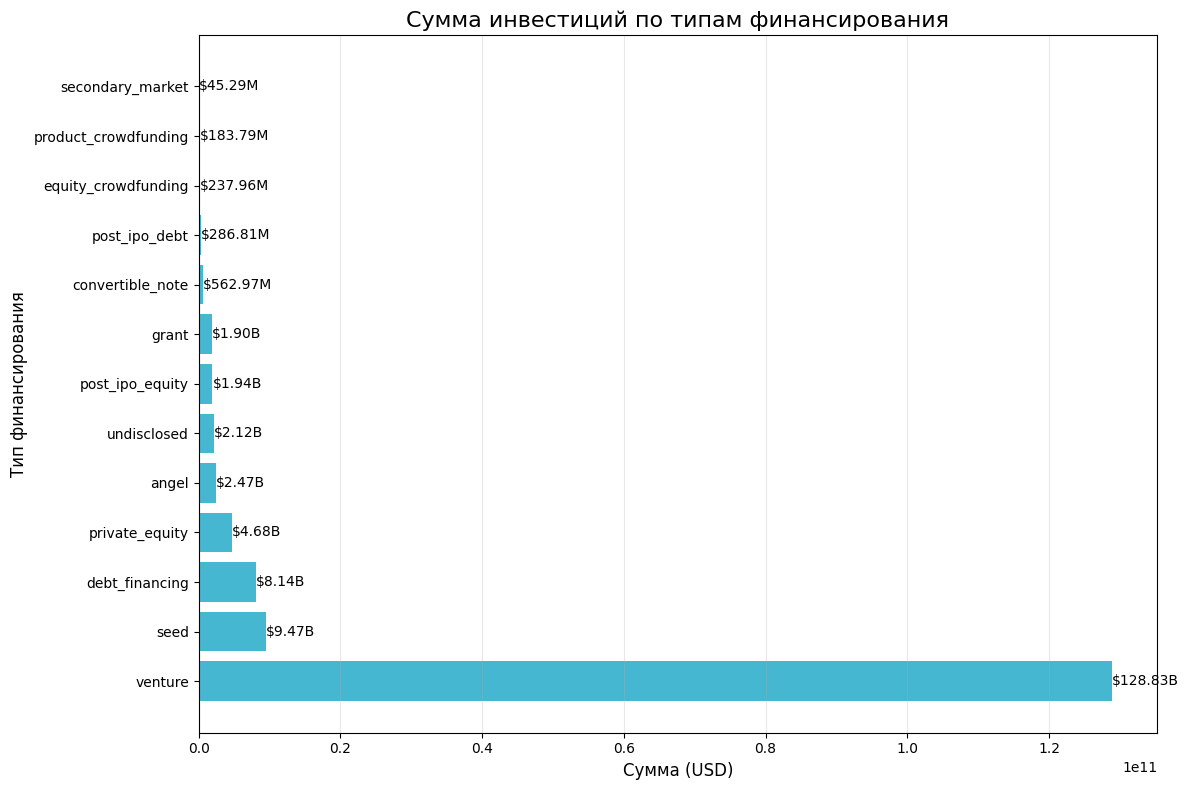

Сумма инвестиций по типам финансирования:
  venture: $128.83 млрд
  seed: $9.47 млрд
  debt_financing: $8.14 млрд
  private_equity: $4.68 млрд
  angel: $2.47 млрд
  undisclosed: $2.12 млрд
  post_ipo_equity: $1.94 млрд
  grant: $1.90 млрд
  convertible_note: $562.97 млн
  post_ipo_debt: $286.81 млн
  equity_crowdfunding: $237.96 млн
  product_crowdfunding: $183.79 млн
  secondary_market: $45.29 млн


In [34]:
# Список типов финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant', 
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                 'secondary_market', 'product_crowdfunding']

# Суммируем инвестиции по каждому типу
funding_sums = df[funding_types].sum().sort_values(ascending=False)

# Выводим результаты
print("Сумма инвестиций по типам финансирования:")
for funding_type, amount in funding_sums.items():
    if amount >= 1e9:
        print(f"  {funding_type}: ${amount/1e9:.2f} млрд")
    elif amount >= 1e6:
        print(f"  {funding_type}: ${amount/1e6:.2f} млн")
    else:
        print(f"  {funding_type}: ${amount:,.0f}")

# Строим горизонтальную столбчатую диаграмму
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(funding_sums.index, funding_sums.values, color='#45B7D1')

# Добавляем значения на столбцы
for i, v in enumerate(funding_sums.values):
    if v >= 1e9:
        label = f'${v/1e9:.2f}B'
    elif v >= 1e6:
        label = f'${v/1e6:.2f}M'
    else:
        label = f'${v:,.0f}'
    ax.text(v, i, label, va='center', fontsize=10)

ax.set_title('Сумма инвестиций по типам финансирования', fontsize=16)
ax.set_xlabel('Сумма (USD)', fontsize=12)
ax.set_ylabel('Тип финансирования', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

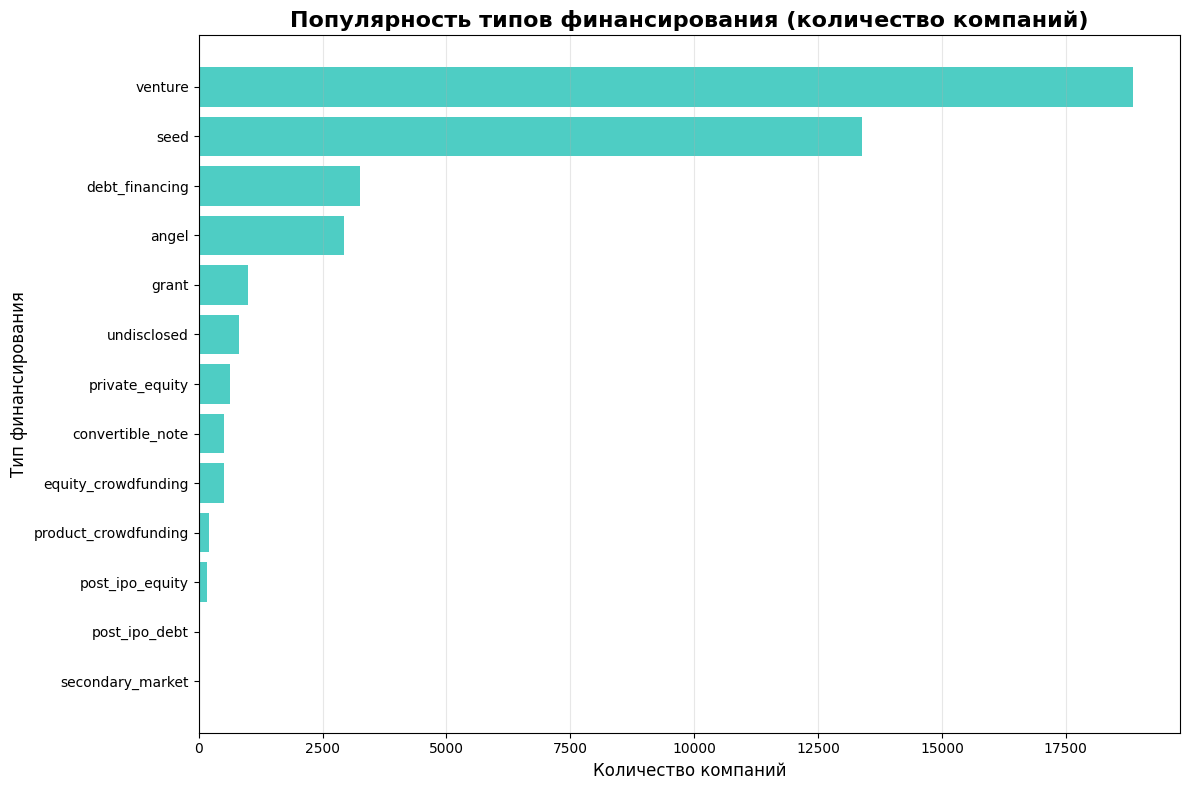

Количество компаний по типам финансирования:
  secondary_market: 7 компаний
  post_ipo_debt: 28 компаний
  post_ipo_equity: 165 компаний
  product_crowdfunding: 204 компаний
  equity_crowdfunding: 515 компаний
  convertible_note: 520 компаний
  private_equity: 631 компаний
  undisclosed: 815 компаний
  grant: 1001 компаний
  angel: 2943 компаний
  debt_financing: 3261 компаний
  seed: 13391 компаний
  venture: 18861 компаний


In [35]:
# Считаем количество компаний с ненулевыми значениями (> 0)
funding_counts = (df[funding_types] > 0).sum().sort_values(ascending=True)

# Выводим результаты
print("Количество компаний по типам финансирования:")
for funding_type, count in funding_counts.items():
    print(f"  {funding_type}: {count} компаний")

# Строим линейчатую диаграмму (горизонтальную)
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(funding_counts.index, funding_counts.values, color='#4ECDC4')

ax.set_title('Популярность типов финансирования (количество компаний)', fontsize=16, weight='bold')
ax.set_xlabel('Количество компаний', fontsize=12)
ax.set_ylabel('Тип финансирования', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

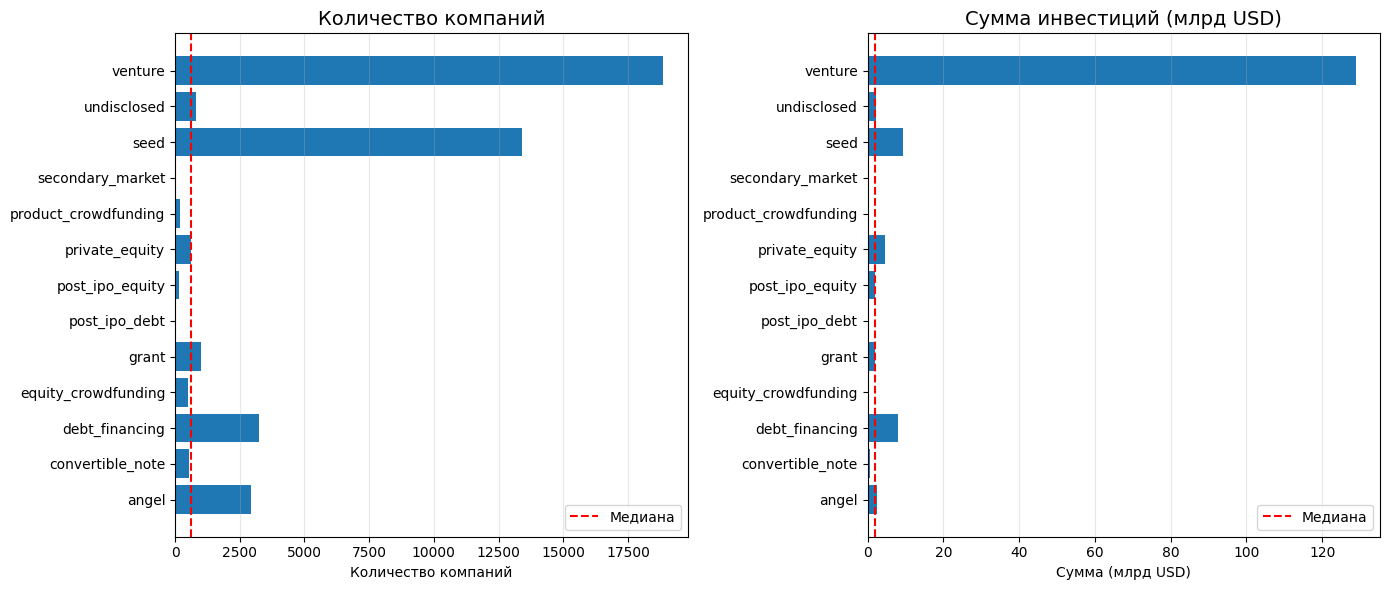

Популярные, но небольшие по объему:
       Компаний  Сумма (млрд)
grant      1001           1.9
Не популярные , но крупные по объему:
Empty DataFrame
Columns: [Компаний, Сумма (млрд)]
Index: []


In [36]:
# Создаем DataFrame для сравнения
comparison = pd.DataFrame({
    'Сумма (млрд)': funding_sums / 1e9,
    'Компаний': funding_counts,
    'Средняя (млн)': (funding_sums / funding_counts) / 1e6
})

# Находим интересные типы
print("Популярные, но небольшие по объему:")
popular_small = comparison[(comparison['Компаний'] > comparison['Компаний'].median()) & 
                           (comparison['Сумма (млрд)'] < comparison['Сумма (млрд)'].median())]
print(popular_small[['Компаний', 'Сумма (млрд)']].round(2))

print("Не популярные , но крупные по объему:")
rare_large = comparison[(comparison['Компаний'] < comparison['Компаний'].median()) & 
                        (comparison['Сумма (млрд)'] > comparison['Сумма (млрд)'].median())]
print(rare_large[['Компаний', 'Сумма (млрд)']].round(2))

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Часто используемые, но небольшие
ax1.barh(comparison.index, comparison['Компаний'])
ax1.set_title('Количество компаний', fontsize=14)
ax1.set_xlabel('Количество компаний')
ax1.axvline(comparison['Компаний'].median(), color='red', linestyle='--', label='Медиана')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# График 2: Редко используемые, но крупные
ax2.barh(comparison.index, comparison['Сумма (млрд)'])
ax2.set_title('Сумма инвестиций (млрд USD)', fontsize=14)
ax2.set_xlabel('Сумма (млрд USD)')
ax2.axvline(comparison['Сумма (млрд)'].median(), color='red', linestyle='--', label='Медиана')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

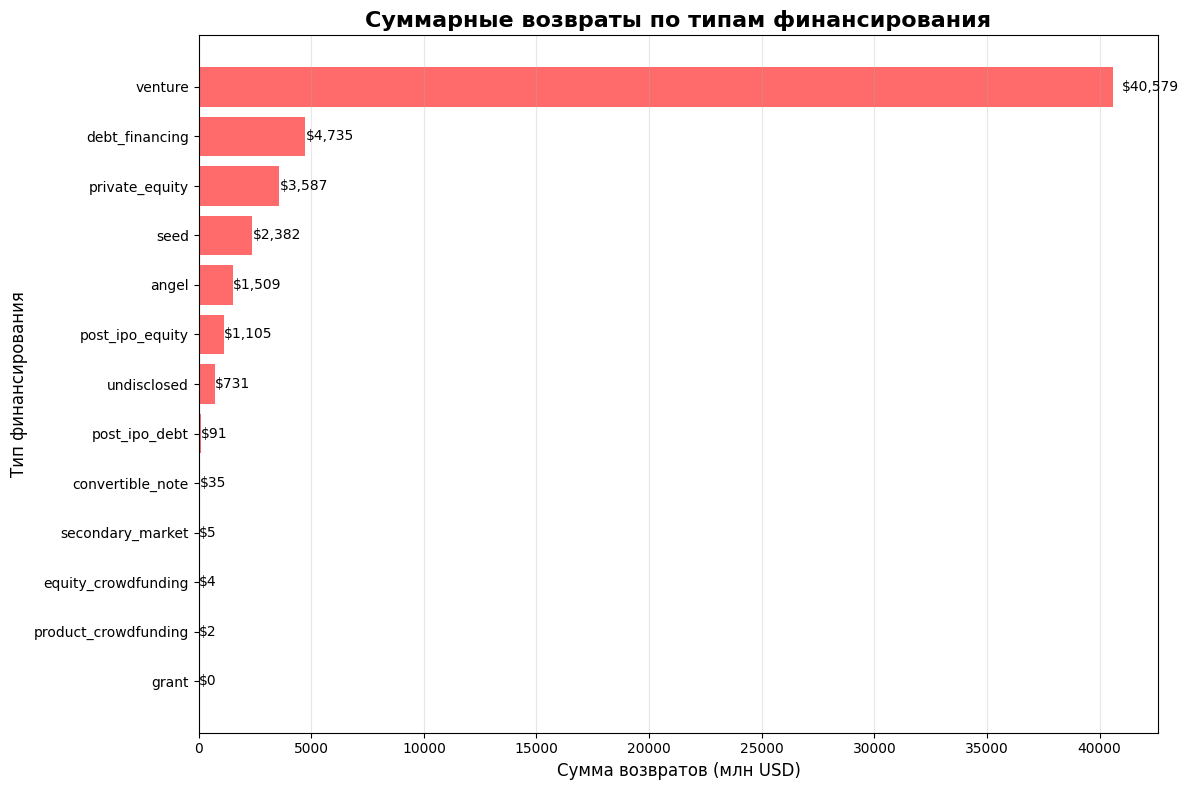

Суммарные возвраты по типам финансирования (за весь период):
  grant: $0
  product_crowdfunding: $2
  equity_crowdfunding: $4
  secondary_market: $5
  convertible_note: $35
  post_ipo_debt: $91
  undisclosed: $731
  post_ipo_equity: $1,105
  angel: $1,509
  seed: $2,382
  private_equity: $3,587
  debt_financing: $4,735
  venture: $40,579


In [37]:
# Суммируем возвраты по каждому типу за все годы
returns_sums = cb[funding_types].sum().sort_values(ascending=True)

# Выводим результаты
print("Суммарные возвраты по типам финансирования (за весь период):")
for funding_type, amount in returns_sums.items():
    if amount >= 1e6:
        print(f"  {funding_type}: ${amount/1e6:.2f} млн")
    else:
        print(f"  {funding_type}: ${amount:,.0f}")

# Строим горизонтальную столбчатую диаграмму
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(returns_sums.index, returns_sums.values, color='#FF6B6B')

# Добавляем значения на столбцы
for i, v in enumerate(returns_sums.values):
    if v >= 1e6:
        label = f'${v/1e6:.2f}M'
    else:
        label = f'${v:,.0f}'
    ax.text(v + v*0.01, i, label, va='center', fontsize=10)

ax.set_title('Суммарные возвраты по типам финансирования', fontsize=16, weight='bold')
ax.set_xlabel('Сумма возвратов (млн USD)', fontsize=12)
ax.set_ylabel('Тип финансирования', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



**Объём инвестиций и популярность.** Наибольший объём привлечённых средств приходится на венчурное финансирование `venture` — $128,8 млрд, что также является самым популярным типом: его используют 18 861 компания.На втором месте по популярности — посевное финансирование `seed` — 13 391 компания, однако его суммарный объём значительно скромнее (9,47 млрд долларов), что указывает на большое количество небольших сделок на ранних стадиях. Долговое финансирование `debt_financing` занимает третье место по объёму (8,14 млрд долларов) и используется 3 261 компанией.

**Редкие типы.** Вторичный рынок `secondary_market`, краудфандинг `equity_crowdfunding`, `product_crowdfunding` и пост-IPO инструменты `post_ipo_equity`, `post_ipo_debt` используются крайне редко (менее 600 компаний), и объёмы у них небольшие — от 45 млн до 1,94 млрд долларов. Редких типов с очень крупными суммами в данных нет. Среди популярных, но небольших по объёму выделяются только гранты `grant`: 1 001 компания и 1,9 млрд долларов.

**Возвраты.** Лидером по объёму возвратов также является венчурное финансирование $40,6 млрд, что почти в 9 раз превышает возвраты от долгового финансирования ($4,7 млрд). Это подтверждает высокую эффективность венчурных инвестиций с точки зрения возвратности. При этом гранты `grant`, краудфандинг и вторичный рынок показывают минимальные возвраты, что может свидетельствовать о низкой ликвидности или длительном горизонте возврата по этим инструментам.

**Сравнение инвестиций и возвратов.** Средняя доля возврата (возвраты / инвестиции) выше всего у `angel`, `post_ipo_equity`, `debt_financing` и `private_equity` — около 56–57%. Посевное (48,7%) и венчурное (39,4%) финансирование возвращают меньшую долю, что соответствует природе ранних стадий с высокими рисками, а краудфандинг, гранты и конвертируемые займы возвращают почти ничего.

Таким образом, венчурное финансирование является доминирующим инструментом как по объёму инвестиций, так и по возвратам, и популярности. Долговое финансирование и посевные инвестиции также играют важную роль, но на разных этапах развития компаний. Редкие типы финансирования, такие как краудфандинг и вторичный рынок, показывают низкую возвратность и используются ограниченным кругом компаний, что делает их менее привлекательными для широкого применения. Для повышения эффективности инвестиционного портфеля рекомендуется фокусироваться на венчурных и долговых инструментах как наиболее сбалансированных по соотношению риска и доходности.



## Анализ динамики

### Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

,name,funding_total_usd,funding_rounds,avg_round_size
1,University of New Brunswick,2000000.0,1.0,2.000000e+06
2,DuPont,9000000.0,1.0,9.000000e+06
3,University of Michigan,7700000.0,3.0,2.566667e+06
4,Case Western Reserve University,540000.0,1.0,5.400000e+05
6,Tulane University,12000000.0,4.0,3.000000e+06
7,Duke University,8700000.0,1.0,8.700000e+06
9,WeGame,3500000.0,2.0,1.750000e+06
11,Mayne Pharma,2705000.0,1.0,2.705000e+06
12,Siemens,8900000.0,1.0,8.900000e+06
16,Michigan State University,3900000.0,1.0,3.900000e+06


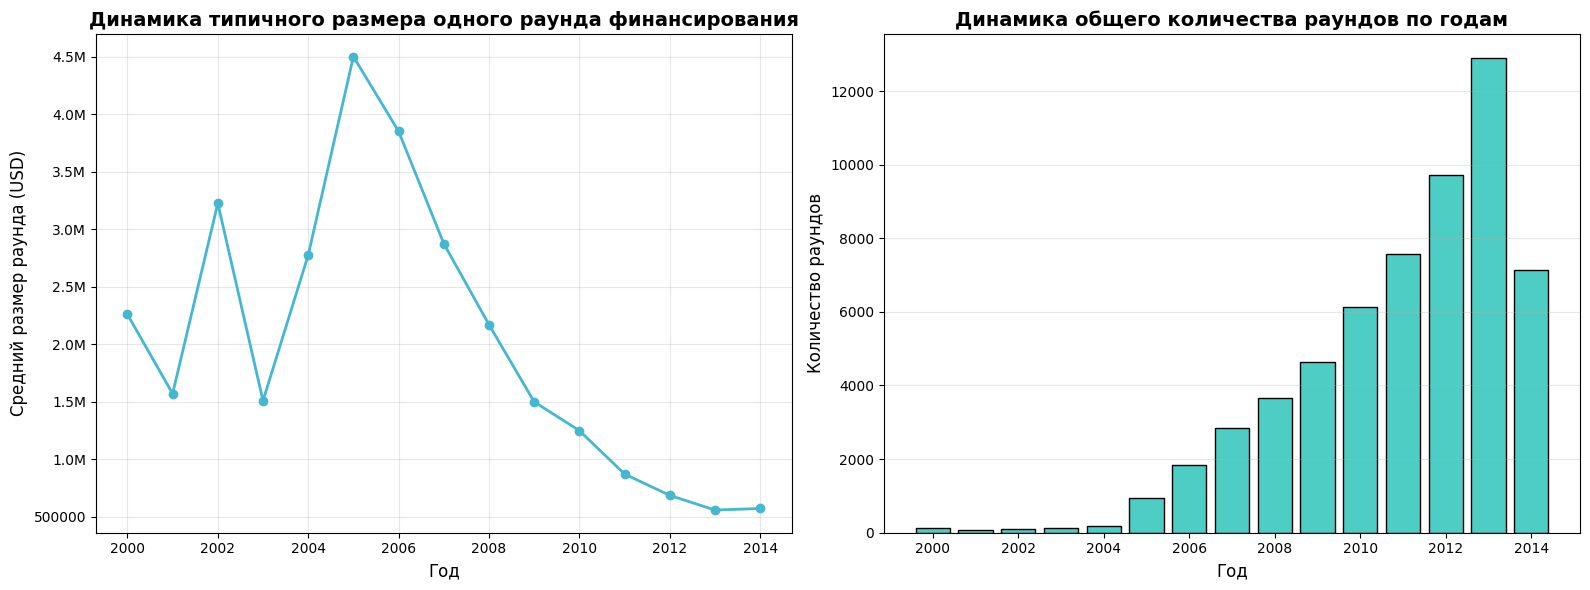

Средний объём одного раунда финансирования (первые 10 компаний):

Динамика типичного размера раунда (медиана) по годам:
funding_year
2000.0    2.260234e+06
2001.0    1.570886e+06
2002.0    3.225000e+06
2003.0    1.510000e+06
2004.0    2.775000e+06
2005.0    4.500000e+06
2006.0    3.850000e+06
2007.0    2.875000e+06
2008.0    2.170744e+06
2009.0    1.500000e+06
2010.0    1.250000e+06
2011.0    8.730005e+05
2012.0    6.875000e+05
2013.0    5.600000e+05
2014.0    5.735170e+05
Name: avg_round_size, dtype: float64

Динамика количества раундов по годам:
funding_year
2000.0      117.0
2001.0       66.0
2002.0       98.0
2003.0      129.0
2004.0      172.0
2005.0      943.0
2006.0     1852.0
2007.0     2842.0
2008.0     3671.0
2009.0     4647.0
2010.0     6146.0
2011.0     7580.0
2012.0     9706.0
2013.0    12907.0
2014.0     7146.0
Name: funding_rounds, dtype: float64


In [38]:
# Рассчитываем средний объём одного раунда для каждой компании
df['avg_round_size'] = df['funding_total_usd'] / df['funding_rounds']

# Проверяем результат
print("Средний объём одного раунда финансирования (первые 10 компаний):")
display(df[['name', 'funding_total_usd', 'funding_rounds', 'avg_round_size']].head(10))

# Группируем по годам (используем funding_year)
# Динамика типичного размера раунда (медиана по годам)
avg_round_by_year = df.groupby('funding_year')['avg_round_size'].median().dropna()

# Динамика количества раундов по годам
rounds_count_by_year = df.groupby('funding_year')['funding_rounds'].sum().dropna()

#  Выводим результаты
print("\nДинамика типичного размера раунда (медиана) по годам:")
print(avg_round_by_year)

print("\nДинамика количества раундов по годам:")
print(rounds_count_by_year)

# Строим графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Динамика типичного размера раунда
ax1.plot(avg_round_by_year.index, avg_round_by_year.values, marker='o', linewidth=2, color='#45B7D1')
ax1.set_title('Динамика типичного размера одного раунда финансирования', fontsize=14, weight='bold')
ax1.set_xlabel('Год', fontsize=12)
ax1.set_ylabel('Средний размер раунда (USD)', fontsize=12)
ax1.grid(alpha=0.3)

# Форматируем подписи на оси Y
def format_y(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}B'
    elif x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x:.0f}'

from matplotlib.ticker import FuncFormatter
ax1.yaxis.set_major_formatter(FuncFormatter(format_y))

# График 2: Динамика количества раундов
ax2.bar(rounds_count_by_year.index, rounds_count_by_year.values, color='#4ECDC4', edgecolor='black')
ax2.set_title('Динамика общего количества раундов по годам', fontsize=14, weight='bold')
ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('Количество раундов', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Максимальный типичный размер средств, собранных в рамках одного раунда финансирования, наблюдался в 2005 году и составил 4,5 млн долларов. В последующие годы этот показатель демонстрировал устойчивую тенденцию к снижению: к 2014 году медианный размер раунда упал до 573,5 тыс. долларов.

Что касается 2014 года, то в этом периоде наблюдалась противоположная динамика: количество раундов финансирования сократилось по сравнению с 2013 годом (с 12 907 до 7 146 раундов), а типичный размер одного раунда остался на низком уровне (менее 600 тыс. долларов). Это может свидетельствовать о насыщении рынка, снижении инвестиционной активности или переходе инвесторов к более осторожной стратегии вложений.

Таким образом, в рассматриваемый период наблюдался тренд на дробление инвестиций: количество раундов росло вплоть до 2013 года, но средний размер каждого раунда уменьшался. Это указывает на переход рынка от крупных сделок к более частым, но менее значительным вложениям, что характерно для этапа зрелости венчурного рынка.

###  Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Рассматриваем только массовые сегменты, а средние и нишевые исключим.

[' Apps ', ' Cloud Computing ', ' Entertainment ', ' Internet ', ' Medical ', ' Networking ', ' Photography ', ' Real Estate ', ' Startups ', ' Technology ', ' Video ', 'E-Commerce ', 'unknown']

market,Apps,Cloud Computing,Entertainment,Internet,Medical,Networking,Photography,Real Estate,Startups,Technology,Video,E-Commerce,unknown
funding_year,,,,,,,,,,,,,
2000.0,0.0,11500000.0,100000.0,10000000.0,24000000.0,0.0,0.0,2500000.0,0.0,0.0,0.0,0.0,1839560.0
2001.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22160000.0,0.0,0.0,10160345.0
2002.0,0.0,0.0,0.0,1100000.0,0.0,0.0,0.0,5275000.0,0.0,2500000.0,0.0,0.0,242132.0
2003.0,0.0,0.0,0.0,0.0,0.0,0.0,7100000.0,6292200.0,0.0,0.0,5000000.0,0.0,4155202.0
2004.0,0.0,0.0,0.0,10500000.0,0.0,0.0,0.0,0.0,0.0,1750000.0,14704000.0,0.0,10847977.0
2005.0,0.0,0.0,10000000.0,1775000.0,11090000.0,0.0,7000000.0,250000.0,0.0,50728425.0,5000000.0,0.0,28384331.0
2006.0,1310600.0,9666354.0,1800000.0,5000.0,20250000.0,26889850.0,17936406.0,2080000.0,0.0,22791000.0,55321772.0,1120000.0,46049840.0
2007.0,0.0,20354343.0,31224025.0,4455379.0,2100000.0,43745721.0,21315000.0,19710000.0,0.0,180190209.0,71380644.0,0.0,35532468.0
2008.0,4300000.0,44375000.0,11150000.0,21412964.0,28812744.0,30807000.0,28949322.0,46613100.0,5010387.0,338226238.0,37865177.0,5558510.0,45345010.0


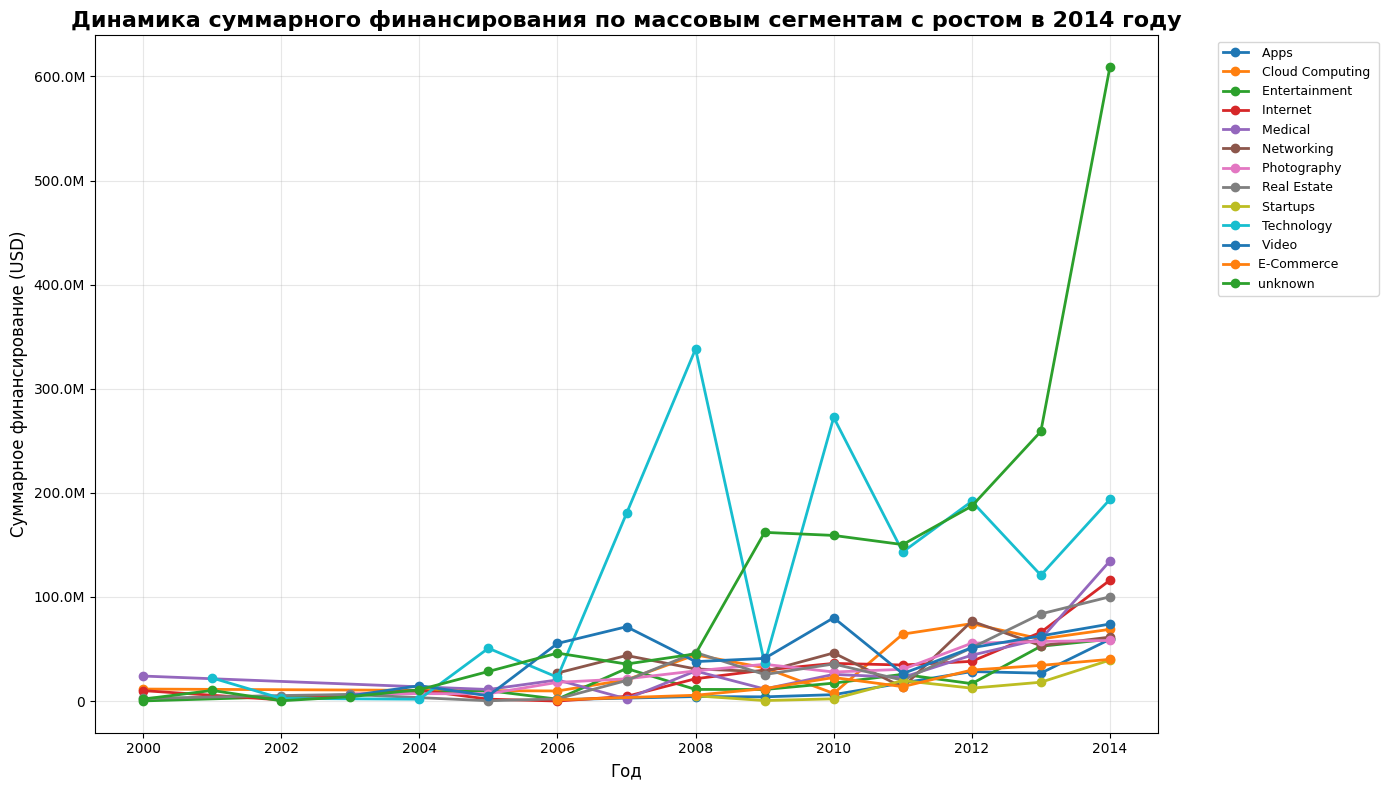

Сегменты с ростом финансирования в 2014 году:

Сводная таблица (суммарное финансирование по годам и сегментам):


In [39]:
# Оставляем только массовые сегменты
# (сегменты, которые сохранили свои названия, а не стали 'mid' или 'niche')
massive_segments = df[~df['market'].isin(['mid', 'niche'])].copy()

# Создаем сводную таблицу: суммарное финансирование по годам и сегментам
pivot_table = massive_segments.pivot_table(
    values='funding_total_usd',
    index='funding_year',
    columns='market',
    aggfunc='sum',
    fill_value=0
)

# Оставляем только сегменты, которые были в 2013 и 2014 годах
years_available = pivot_table.index
if 2013 in years_available and 2014 in years_available:
    # Выбираем сегменты с ростом в 2014 году
    growth_mask = pivot_table.loc[2014] > pivot_table.loc[2013]
    growing_segments = pivot_table.columns[growth_mask]
    print("Сегменты с ростом финансирования в 2014 году:")
    display(growing_segments.tolist())
    # Оставляем только растущие сегменты
    pivot_table_growth = pivot_table[growing_segments]
else:
    print("Данные за 2013 или 2014 год отсутствуют")
    pivot_table_growth = pivot_table

# Выводим сводную таблицу
print("\nСводная таблица (суммарное финансирование по годам и сегментам):")
display(pivot_table_growth)

# Строим график
fig, ax = plt.subplots(figsize=(14, 8))

# Строим линии для каждого сегмента
for segment in pivot_table_growth.columns:
    # Берем только годы с данными (убираем нулевые значения)
    data = pivot_table_growth[segment]
    data = data[data > 0]
    if not data.empty:
        ax.plot(data.index, data.values, marker='o', linewidth=2, label=segment)

ax.set_title('Динамика суммарного финансирования по массовым сегментам с ростом в 2014 году', fontsize=16, weight='bold')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Суммарное финансирование (USD)', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Форматируем подписи на оси Y
def format_y(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}B'
    elif x >= 1e6:
        return f'{x/1e6:.1f}M'
    else:
        return f'{x:.0f}'

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(format_y))

plt.tight_layout()
plt.show()

Наиболее быстрый и уверенный рост среди массовых сегментов демонстрируют `Medical` и `Internet`: в 2011–2014 годах их суммарное финансирование росло каждый год — у `Medical` с 22,7 до 134,5 млн USD, у `Internet` с 34,6 до 116,0 млн USD. Это свидетельствует о высокой инвестиционной привлекательности данных направлений.

Стабильный рост, но на меньших объёмах, наблюдается у `Real Estate` (с 20,0 до 100,1 млн USD за 2011–2014 годы), `Video` (с 26,3 до 74,0 млн USD) и `E-Commerce` (с 13,8 до 40,0 млн USD).

Рост с колебаниями демонстрируют `Apps` (спад в 2013 году, затем рост до 59,3 млн USD в 2014), `Entertainment` (спад в 2012 году), `Networking`, `Cloud Computing` (68,9 млн USD в 2014 году, ниже пика 2012 года — 74,4 млн) и `Technology`. У последнего самые крупные объёмы среди перечисленных (338 млн USD в 2008 году, 194 млн USD в 2014), но устойчивой динамики нет. `Photography` и `Startups` растут медленно или с небольшой базы.

Отдельно стоит `unknown` — это не отрасль, а компании, у которых рынок не указан. Их суммарное финансирование выросло до 609 млн USD в 2014 году, но для инвестиционных выводов эта группа не подходит.

Таким образом, наиболее перспективными и быстрорастущими сегментами являются `Medical`, `Internet` и `Real Estate`, а из менее крупных — `Video` и `E-Commerce`. Инвесторам рекомендуется фокусироваться на этих направлениях, так как они показывают устойчивый рост и высокую инвестиционную активность.

### Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [40]:
# Функция для форматирования
def format_money(x):
    if pd.isna(x):
        return 'N/A'
    if x >= 1e9:
        return f'${x/1e9:.2f}B'
    elif x >= 1e6:
        return f'${x/1e6:.2f}M'
    else:
        return f'${x:,.0f}'

# Суммируем
invest = df.groupby('funding_year')[funding_types].sum()
ret = cb.groupby('year')[funding_types].sum() * 1_000_000

invest.index = invest.index.astype(int)
ret.index = ret.index.astype(int)

data = invest.join(ret, lsuffix='_inv', rsuffix='_ret', how='inner')

# Считаем долю возврата
for t in funding_types:
    data[f'{t}_return'] = data[f'{t}_ret'] / (data[f'{t}_inv'] + 1e-60)
    data[f'{t}_return'] = data[f'{t}_return'].where(
        (data[f'{t}_return'] >= 0) & (data[f'{t}_return'] <= 1)
    )

for t in funding_types:
    inv_total = data[f'{t}_inv'].sum()
    ret_total = data[f'{t}_ret'].sum()
    ratio = data[f'{t}_return'].mean()
    
    if not pd.isna(ratio):
        print(f"\n{t}:")
        print(f"  Инвестиции: {format_money(inv_total)}")
        print(f"  Возвраты: {format_money(ret_total)}")
        print(f"  Доля возврата: {ratio:.4f} ({ratio*100:.1f}%)")


seed:
  Инвестиции: $9.47B
  Возвраты: $2.38B
  Доля возврата: 0.4867 (48.7%)

venture:
  Инвестиции: $128.83B
  Возвраты: $40.58B
  Доля возврата: 0.3942 (39.4%)

equity_crowdfunding:
  Инвестиции: $237.96M
  Возвраты: $3.83M
  Доля возврата: 0.0386 (3.9%)

undisclosed:
  Инвестиции: $2.12B
  Возвраты: $730.88M
  Доля возврата: 0.4727 (47.3%)

convertible_note:
  Инвестиции: $562.97M
  Возвраты: $34.79M
  Доля возврата: 0.0725 (7.2%)

debt_financing:
  Инвестиции: $8.14B
  Возвраты: $4.73B
  Доля возврата: 0.5616 (56.2%)

angel:
  Инвестиции: $2.47B
  Возвраты: $1.51B
  Доля возврата: 0.5705 (57.0%)

grant:
  Инвестиции: $1.90B
  Возвраты: $0
  Доля возврата: 0.0000 (0.0%)

private_equity:
  Инвестиции: $4.68B
  Возвраты: $3.59B
  Доля возврата: 0.5564 (55.6%)

post_ipo_equity:
  Инвестиции: $1.94B
  Возвраты: $1.10B
  Доля возврата: 0.5660 (56.6%)

post_ipo_debt:
  Инвестиции: $286.81M
  Возвраты: $91.03M
  Доля возврата: 0.1436 (14.4%)

secondary_market:
  Инвестиции: $45.29M
  Воз

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

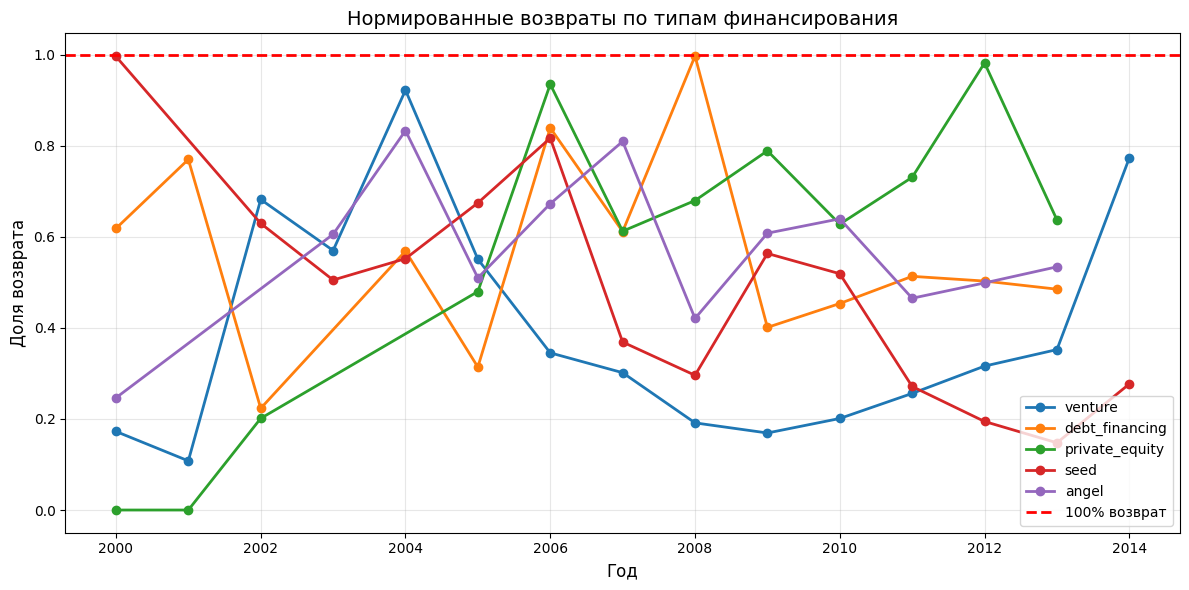


venture:
  Инвестиции: $128.83B
  Возвраты: $40.58B
  Доля возврата: 0.3942 (39.4%)

debt_financing:
  Инвестиции: $8.14B
  Возвраты: $4.73B
  Доля возврата: 0.5616 (56.2%)

private_equity:
  Инвестиции: $4.68B
  Возвраты: $3.59B
  Доля возврата: 0.5564 (55.6%)

seed:
  Инвестиции: $9.47B
  Возвраты: $2.38B
  Доля возврата: 0.4867 (48.7%)

angel:
  Инвестиции: $2.47B
  Возвраты: $1.51B
  Доля возврата: 0.5705 (57.0%)


In [41]:
# Выбираем основные типы
types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Функция для форматирования
def format_money(x):
    if pd.isna(x):
        return 'N/A'
    if x >= 1e9:
        return f'${x/1e9:.2f}B'
    elif x >= 1e6:
        return f'${x/1e6:.2f}M'
    else:
        return f'${x:,.0f}'

# Суммируем
invest = df.groupby('funding_year')[types].sum()
ret = cb.groupby('year')[types].sum() * 1_000_000

invest.index = invest.index.astype(int)
ret.index = ret.index.astype(int)

data = invest.join(ret, lsuffix='_inv', rsuffix='_ret', how='inner')

# Считаем долю возврата
for t in types:
    data[f'{t}_return'] = data[f'{t}_ret'] / (data[f'{t}_inv'] + 1e-60)
    data[f'{t}_return'] = data[f'{t}_return'].where(
        (data[f'{t}_return'] >= 0) & (data[f'{t}_return'] <= 1)
    )

for t in types:
    inv_total = data[f'{t}_inv'].sum()
    ret_total = data[f'{t}_ret'].sum()
    ratio = data[f'{t}_return'].mean()
    
    if not pd.isna(ratio):
        print(f"\n{t}:")
        print(f"  Инвестиции: {format_money(inv_total)}")
        print(f"  Возвраты: {format_money(ret_total)}")
        print(f"  Доля возврата: {ratio:.4f} ({ratio*100:.1f}%)")

# График
plt.figure(figsize=(12, 6))

for t in types:
    data_clean = data[f'{t}_return'].dropna()
    if not data_clean.empty:
        plt.plot(data_clean.index, data_clean.values, marker='o', linewidth=2, label=t)

plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='100% возврат')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возврата', fontsize=12)
plt.title('Нормированные возвраты по типам финансирования', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Лидеры по доле возврата.** Наиболее высокую среднюю долю возврата демонстрируют `angel` (57,0%), `post_ipo_equity` (56,6%), `debt_financing` (56,2%; возвращено 4,73 млрд из 8,14 млрд) и `private_equity` (55,6%; возвращено 3,59 млрд из 4,68 млрд). Разница между ними невелика: во всех четырёх случаях возвращается около 56–57% вложенных средств.

**Средний уровень возврата.** Seed-инвестиции демонстрируют долю возврата 48,7% (2,38 млрд из 9,47 млрд), что соответствует их природе как инструмента поддержки стартапов на самых ранних стадиях с высокими рисками. `Venture` инвестиции показывают 39,4% (40,58 млрд из 128,83 млрд): при самой низкой доле возврата среди основных типов это самый большой абсолютный возврат.

**Низкая возвратность.** Наименьшую долю возврата демонстрируют `product_crowdfunding` (1,3%), `equity_crowdfunding` (3,9%) и `convertible_note` (7,2%). Это указывает на высокие риски и низкую ликвидность этих инструментов. Grant показывает нулевой возврат, что соответствует их безвозмездной природе.

**Динамика по годам.** Наиболее устойчивый рост доли возврата показывает `venture`: после минимума в 2009 году (17%) она росла каждый год — 20%, 26%, 32% и 35% в 2013 году, а в 2014 году достигла 77% (значение за 2014 год стоит трактовать осторожно, так как данные по инвестициям за этот год неполные). У `debt_financing` с 2009 года доля держится на уровне 40–51% без выраженного роста, у `angel` — 47–64%. `Private_equity` имеет высокую, но скачущую по годам долю (63–98% в 2009–2013 годах), а у `seed` показатель снижается: с 52% в 2010 году до 15% в 2013 году.

**Общий вывод.** Наиболее эффективными типами финансирования по средней доле возврата являются `angel`, `debt_financing` и `private_equity`: они возвращают более 55% вложенных средств и могут быть рекомендованы для консервативных инвестиционных стратегий. Для агрессивных стратегий с высоким потенциалом роста, но повышенными рисками, подходят `venture` и `seed`. Венчурное финансирование при низкой средней доле возврата (39,4%) показывает наиболее устойчивый рост этого показателя в последние годы. Краудфандинговые инструменты и гранты демонстрируют крайне низкую возвратность и не рекомендуются для инвестиций с целью получения прибыли.


##  Итоговый вывод и рекомендации

**Рекомендация 1:** Стоит присмотреться к двум быстрорастущим массовым сегментам: `Medical` и `Internet`.

**Обоснование:** 
- Устойчивый и уверенный рост. Согласно анализу динамики финансирования, именно эти сегменты демонстрируют наиболее стабильный и уверенный рост суммарного объёма инвестиций вплоть до 2014 года. В то время как другие сегменты показывали колебания, `Medical` и `Internet` показали устойчивую восходящую траекторию.
- Масштаб рынка. Это массовые сегменты (с более чем 120 компаниями в выборке), что гарантирует высокую ликвидность и большое количество потенциальных объектов для инвестирования.
- Актуальность. В 2015 году тренды на цифровизацию `Internet` и развитие здравоохранения `Medical` продолжали набирать обороты, что делает эти направления крайне перспективными.
- В качестве дополнительного, но более рискованного варианта можно рассмотреть сегменты `Real Estate` (рост с 20 до 100 млн USD за 2011–2014 годы) и `E-Commerce`, которые также показывают уверенный рост, хотя и с меньшими объёмами.

**Рекомендация 2:** Наиболее уместным типом финансирования для инвестиций в указанные сегменты является венчурное финансирование `venture`.

**Обоснование:** 
- Доминирование по объёму и популярности. `Ventur`e является самым популярным типом финансирования, используемым 18 861 компанией, и аккумулирует абсолютный объём инвестиций — $128.8 млрд. Это основной инструмент для масштабирования бизнеса в технологичных и наукоёмких отраслях.  
- Высокая возвратность. С долей возврата 39,4% (возвращено 40,58 млрд из 128,83 млрд) венчурные инвестиции показывают наибольший абсолютный возврат среди всех типов и значительно опережают по объёму возвратов все остальные инструменты, включая `private_equity`. Кроме того, именно у `venture` доля возврата устойчиво росла с 2009 года (с 17% до 35% к 2013 году).
- Соответствие сегментам. Сегменты `Medical` и `Internet` являются классическими бенефициарами венчурного капитала, который позволяет финансировать высокорисковые, но потенциально сверхприбыльные проекты на этапах активного роста.

В качестве альтернативы для более консервативной стратегии можно рассмотреть `debt_financing` — оно показывает высокую долю возврата (56,2%) и является более предсказуемым инструментом. Однако оно менее подходит для быстрого роста стартапов на ранних стадиях.

**Итоги проекта:** 

- **Предобработка данных:** Загрузили и очистили данные (`cb_investments.zip` и `cb_returns.csv`), удалив дубликаты, пропуски и аномалии (выбросы). Привели типы данных к корректному формату (числа и даты). Отбросили около 25 процентов некорректных данных, чтобы обеспечить чистоту анализа.

- **Сегментация и классификация:** Разделили компании по срокам финансирования и выяснили, что большинство имеют лишь один раунд, но основной объём инвестиций уходит в компании с долгосрочной историей финансирования.
Классифицировали более 800 рыночных сегментов на массовые , средние и нишевые. Это позволило сфокусироваться на самых репрезентативных направлениях (`Software`, `Biotech`, `Mobile` и др.).

- **Анализ выбросов:** Оценили типичные и аномальные объёмы финансирования. Мы выяснили, что типичный размер финансирования для компании лежит в диапазоне от 350 тыс. до 10 млн. Компании за пределами этого диапазона были исключены, чтобы не искажать статистику.

- **Сравнение типов финансирования:** Детально проанализировали 13 типов финансирования.
Ключевой вывод:`Venture` — абсолютный лидер по объёму и популярности. `Seed` — второй по популярности, но с меньшим объёмом. `Angel`, `debt_financing` и `private_equity` — самые высокие доли возврата (55–57%).

- **Неэффективные инструменты:** Краудфандинговые инструменты и гранты показали крайне низкую или нулевую возвратность, что делает их непригодными для целей получения прибыли.

- **Анализ динамики:**
Размер раундов: Увидели тревожный, но логичный тренд: типичный размер одного раунда финансирования сокращался с 4.5 млн в 2005 году до 0.57 млн в 2014 году. Это говорит о "дроблении" инвестиций и росте числа более мелких сделок.  
Рост сегментов: Выявили `Medical` и `Internet` как самые быстрорастущие массовые сегменты, что и легло в основу главной рекомендации.
Анализ возвратности: Рассчитали долю возврата для каждого типа. Выяснили, что наиболее устойчивый рост доли возврата демонстрирует `venture` (с 17% в 2009 до 35% в 2013 году), тогда как у `private_equity` и `angel` показатель высокий, но колеблется по годам, а у `seed` снижается.


**Согласованность выводов:**  
Все выводы логически непротиворечивы и дополняют друг друга:
- Рекомендация `Medical` и `Internet` базируется на объективных данных о росте и является наиболее "безрисковым" выбором среди быстрорастущих сегментов.
- Рекомендация `Venture` подтверждается его доминирующей ролью на рынке и коррелирует с потребностями быстрорастущих компаний. В то время как `private_equity` показывает более высокую среднюю долю возврата (55,6% против 39,4%), он менее подходит для инвестиций на стадиях роста, характерных для выделенных сегментов.
- Единственное противоречие, которое мы наблюдаем — это рост количества раундов при падении их среднего размера. Это говорит не о "охлаждении" рынка, а о его эволюции. Инвесторы стали более осторожными, предпочитая "проверять" стартап небольшими суммами на каждом этапе, прежде чем вкладывать крупные средства.

**Заключительный совет:**  
В 2015 году ваша инвестиционная стратегия должна быть нацелена на быстрорастущие технологические и медицинские ниши (`Medical`, `Internet`), используя для этого венчурное финансирование. Будьте готовы к тому, что рынок становится более "дробным", и для достижения цели вам, возможно, придётся участвовать в нескольких раундах финансирования одной компании, а не вкладывать все средства сразу.